In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 先生成一个low rank矩阵
t = np.arange(-3,3,0.01)

U_true = np.array([np.cos(17*t) * np.exp(-t**2), np.sin(11*t)]).T
Sigma_true = np.array([[2, 0],[0, 0.5]])
V_true = np.array([np.sin(5*t) * np.exp(-t**2), np.cos(13*t)]).T


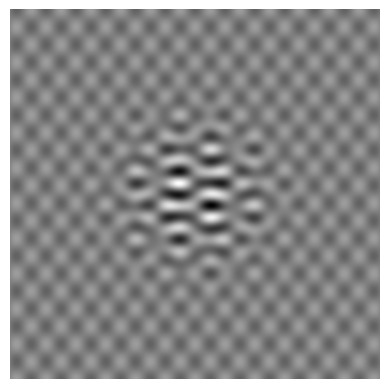

In [3]:
X = U_true @ Sigma_true @ V_true.T

plt.imshow(X)
plt.set_cmap('gray')
plt.axis('off')
plt.show()

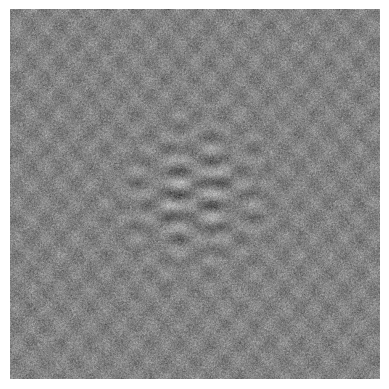

In [4]:
# 将噪声加到X上
gamma = 1 # 噪声强度参数
X_noisy = X + gamma * np.random.randn(*X.shape)
plt.imshow(X_noisy)
plt.set_cmap('gray')
plt.axis('off')
plt.show()


In [5]:
# 进行 SVD 分解带有噪声的X（即：X_noisy）
U, Sigma, V_T = np.linalg.svd(X_noisy, full_matrices=False)


In [6]:
# 计算optimal hard threshold
n = X.shape[0]
tau = (4/np.sqrt(3)) * np.sqrt(n) * gamma

In [7]:
idx = np.max(np.where(Sigma > tau))

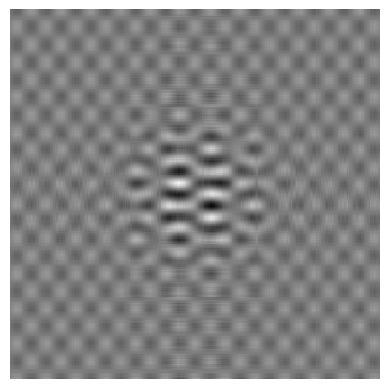

In [8]:
X_clean = U[:,:(idx+1)] @ np.diag(Sigma[:(idx+1)]) @ V_T[:(idx+1),:]
plt.imshow(X_clean)
plt.set_cmap('gray')
plt.axis('off')
plt.show()


In [9]:
# 截断90% 
cs = np.cumsum(Sigma) / np.sum(Sigma)
idx_90 = np.min(np.where(cs > 0.9))


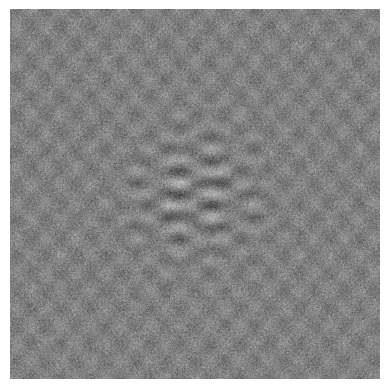

In [10]:
X_90 = U[:,:(idx_90+1)] @ np.diag(Sigma[:(idx_90+1)]) @ V_T[:(idx_90+1),:]
plt.imshow(X_90)
plt.set_cmap('gray')
plt.axis('off')
plt.show()

/var/folders/t9/n3zhf08n4cv_ns10b375thxr0000gn/T/ipykernel_18180/1967785564.py:5: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,300)


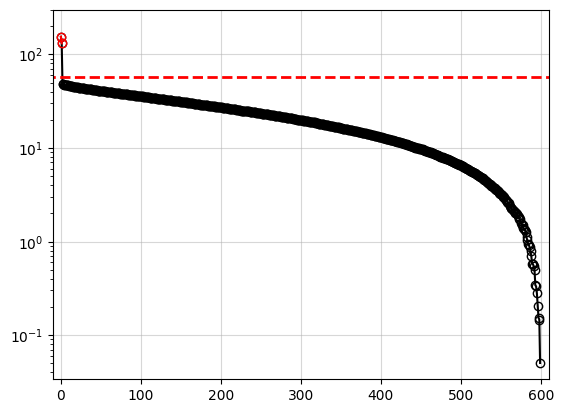

In [11]:
plt.semilogy(Sigma,'-o',color='black',markerfacecolor='none')
plt.semilogy(Sigma[:idx+1],'-o',color='red',markerfacecolor='none')
plt.plot(np.array([-20, n+20]),np.array([tau, tau]),'--', color='r', linewidth=2)
plt.xlim(0-10,600+10)
plt.ylim(0,300)
plt.grid(True,alpha=0.5)
plt.axis('on')
plt.show()


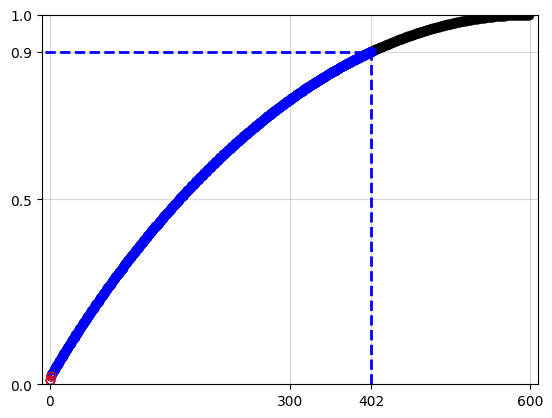

In [12]:
plt.plot(np.cumsum(Sigma)/np.sum(Sigma),'-o',color='black',markerfacecolor='none')
plt.plot(np.cumsum(Sigma[:(idx_90+1)])/np.sum(Sigma),'-o',color='blue',markerfacecolor='none')
plt.plot(np.cumsum(Sigma[:(idx+1)])/np.sum(Sigma),'-o',color='red',markerfacecolor='none')
plt.xticks(np.array([0, 300, idx_90, 600]))
plt.yticks(np.array([0, 0.5, 0.9, 1]))
plt.plot(np.array([idx_90, idx_90, -10]),np.array([0, 0.9, 0.9]),'--',color='b',linewidth=2)
plt.xlim(0-10,600+10)
plt.ylim(0,1)
plt.grid(True,alpha=0.5)
plt.axis()
plt.show()